# Snow spatial

In [1]:
# librariies
import xarray as xr
import numpy as np
import pandas as pd

import rasterio.features
import geopandas as gpd
from shapely.geometry import shape

from netCDF4 import Dataset

from snobedo.snotel import SnotelLocations
from snobedo.snotel import SnotelLocations, CsvParser

from snobedo.lib.dask_utils import start_cluster, client_ip_and_port

from pathlib import Path, PurePath

import matplotlib.pyplot as plt

In [2]:
# DEM INFO
UVU_OLSON_HOME = '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/'
HRRR_DATA = UVU_OLSON_HOME + 'HRRR/'
ERW_TOPO_FILE = UVU_OLSON_HOME + 'isnobal-data/ERW_topo.nc'

with Dataset(ERW_TOPO_FILE) as dem:
    sky_view_factor = dem['sky_view_factor'][:].astype(np.float64)
    dem = dem['dem'][:].astype(np.float64)

In [3]:

# 1. Open dataset and load the mask variable (assumes 'mask' is 2D)
ds = xr.open_dataset(ERW_TOPO_FILE)
mask = ds['mask'].values  # numpy array
x = ds['x'].values  # or ds['lon'].values
y = ds['y'].values  # or ds['lat'].values

from affine import Affine
x_res = (x[-1] - x[0]) / (len(x) - 1)
y_res = (y[-1] - y[0]) / (len(y) - 1)
transform = Affine.translation(x[0] - x_res / 2, y[0] - y_res / 2) * Affine.scale(x_res, y_res)
mask_bool = mask.astype(bool)
shapes_generator = rasterio.features.shapes(mask_bool.astype(np.uint8), transform=transform)
polygons = [shape(geom) for geom, value in shapes_generator if value == 1]
crs = ds.attrs.get('crs', 'EPSG:26913')  # Replace if no CRS attribute or set your own
gdf = gpd.GeoDataFrame({'geometry': polygons}, crs=crs)

print(f"Extracted {len(gdf)} polygons from mask.")


Extracted 1 polygons from mask.


In [4]:
from dask.distributed import Client
from dask_jobqueue import SLURMCluster

cluster = SLURMCluster(
    cores=8,
    processes=4,
    memory="32GB",
    account="notchpeak-shared-short", # project
    queue="notchpeak-shared-short",
    walltime="2:00:00",
)

# Scale the cluster — adjust this based on your workload
cluster.scale(jobs=2)  # e.g., 2 jobs → 2 × 8 = 16 cores total

client = Client(cluster)  # Attach Dask client to the cluster

In [ ]:

start_date = '2021-12-01'
end_date = '2022-05-01'

file_pattern = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/results/isnobal_simulations/hrrr_toposplit/sw/erw_spires_dsw3/wy2022/erw_50m/run*/snow.nc'

isno22 = xr.open_mfdataset(
    file_pattern,
    combine='by_coords',
    parallel=True,
    chunks={'time': 24}
)
mean_dsw3 = isno22['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()


# # # #
file_pattern1 = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/results/isnobal_simulations/hrrr_toposplit/sw/erw_spires_dsw1/wy2022/erw_50m/run*/snow.nc'
isno22_dsw1 = xr.open_mfdataset(
    file_pattern1,
    combine='by_coords',
    parallel=True,
    chunks={'time': 24}
)
mean_dsw1 = isno22_dsw1['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()


# # # # #
file_pattern2 = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/results/isnobal_simulations/hrrr_toposplit/sw/erw_spires_ghi/wy2022/erw_50m/run*/snow.nc'
isno22_ghi = xr.open_mfdataset(
    file_pattern2,
    combine='by_coords',
    parallel=True,
    chunks={'time': 24}
)
mean_ghi = isno22_ghi['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()


dsw3_base = (mean_dsw3 - mean_ghi)
dsw3_shade = (mean_dsw3 - mean_dsw1)
dsw1_base = (mean_dsw1 - mean_ghi)


In [16]:
dsw3_base

<xarray.DataArray 'thickness' (y: 837, x: 656)> Size: 2MB
array([[ 0.15200818,  0.16007471,  0.20347047, ..., -0.03275967,
        -0.03126544, -0.0277074 ],
       [ 0.16200662,  0.18084955,  0.22122061, ..., -0.03788656,
        -0.03609353, -0.03257376],
       [ 0.18216896,  0.2222637 ,  0.24187946, ..., -0.04470199,
        -0.04289776, -0.03983843],
       ...,
       [-0.02768667,  0.00788829,  0.05463079, ..., -0.01484054,
        -0.01258743, -0.02061082],
       [ 0.07145268,  0.11376414,  0.1327768 , ..., -0.02380894,
        -0.02908986, -0.03356516],
       [ 0.11790314,  0.14539719,  0.1595065 , ..., -0.0264802 ,
        -0.03134359, -0.04243679]], dtype=float32)
Coordinates:
  * y        (y) float32 3kB 4.323e+06 4.323e+06 ... 4.281e+06 4.281e+06
  * x        (x) float32 3kB 3.159e+05 3.16e+05 3.16e+05 ... 3.486e+05 3.487e+05

In [ ]:

start_date = '2022-02-01'
end_date = '2022-02-28'

feb_ghi = isno22_ghi['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()
feb_dsw1 = isno22_dsw1['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()
feb_dsw3 = isno22['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()

start_date = '2022-03-01'
end_date = '2022-03-31'

mar_ghi =isno22_ghi['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()
mar_dsw1 = isno22_dsw1['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()
mar_dsw3 = isno22['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()

start_date = '2022-04-01'
end_date = '2022-04-30'

apr_ghi = isno22_ghi['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()
apr_dsw1 = isno22_dsw1['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()
apr_dsw3 = isno22['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()

apr1 = apr_dsw3 - apr_ghi
apr2 = apr_dsw3 - apr_dsw1
apr3 = apr_dsw1 - apr_ghi

mar1 = mar_dsw3 - mar_ghi
mar2 = mar_dsw3 - mar_dsw1
mar3 = mar_dsw1 - mar_ghi

feb1 = feb_dsw3 - feb_ghi
feb2 = feb_dsw3 - feb_dsw1
feb3 = feb_dsw1 - feb_ghi

# December 2021
start_date = '2021-12-01'
end_date = '2021-12-31'

dec_ghi = isno22_ghi['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()
dec_dsw1 = isno22_dsw1['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()
dec_dsw3 = isno22['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()

dec1 = dec_dsw3 - dec_ghi
dec2 = dec_dsw3 - dec_dsw1
dec3 = dec_dsw1 - dec_ghi

# January 2022
start_date = '2022-01-01'
end_date = '2022-01-31'

jan_ghi = isno22_ghi['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()
jan_dsw1 = isno22_dsw1['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()
jan_dsw3 = isno22['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()

jan1 = jan_dsw3 - jan_ghi
jan2 = jan_dsw3 - jan_dsw1
jan3 = jan_dsw1 - jan_ghi

# May 2022
start_date = '2022-05-01'
end_date = '2022-05-31'

may_ghi = isno22_ghi['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()
may_dsw1 = isno22_dsw1['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()
may_dsw3 = isno22['thickness'].sel(time=slice(start_date, end_date)).mean(dim='time').compute()

may1 = may_dsw3 - may_ghi
may2 = may_dsw3 - may_dsw1
may3 = may_dsw1 - may_ghi




In [13]:
may1

<xarray.DataArray 'thickness' (y: 837, x: 656)> Size: 2MB
array([[ 0.40491056,  0.43494236,  0.5399449 , ..., -0.0954718 ,
        -0.09708488, -0.09019756],
       [ 0.43706143,  0.5003108 ,  0.5966606 , ..., -0.10564947,
        -0.10509139, -0.09820098],
       [ 0.49296904,  0.5746225 ,  0.6295389 , ..., -0.11859351,
        -0.11363173, -0.10743535],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], dtype=float32)
Coordinates:
  * y        (y) float32 3kB 4.323e+06 4.323e+06 ... 4.281e+06 4.281e+06
  * x        (x) float32 3kB 3.159e+05 3.16e+05 3.16e+05 ... 3.486e+05 3.487e+05

In [25]:
client

<Client: 'tcp://10.242.76.197:34415' processes=8 threads=16, memory=59.60 GiB>

In [26]:
client.shutdown()

# Plots

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Global font settings
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})

# Color limits and colormap
vmin = min([float(dsw3_base.min()), float(dsw3_shade.min()), float(dsw1_base.min())])
vmax = max([float(dsw3_base.max()), float(dsw3_shade.max()), float(dsw1_base.max())])
vmin, vmax = -0.5, 0.5
abs_max = max(abs(vmin), abs(vmax))
cmap = 'RdBu'
# cmap = 'PuOr_r'

# Set up figure with GridSpec for clean layout including colorbar
fig = plt.figure(figsize=(16, 6), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(1, 4, figure=fig, width_ratios=[1, 1, 1, 0.05])

# Axes for plots
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
cax = fig.add_subplot(gs[3])  # Colorbar axis

# Plot datasets in order: dsw1_base, dsw3_shade, dsw3_base
im0 = dsw1_base.plot(ax=ax0, cmap=cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=False)
dsw3_shade.plot(ax=ax1, cmap=cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=False)
dsw3_base.plot(ax=ax2, cmap=cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=False)


# Overlay polygons with no fill, just boundaries
gdf.plot(ax=ax0, facecolor='none', edgecolor='black', linewidth=1)
gdf.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1)
gdf.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=1)
# import matplotlib.patches as patches


# Add shared colorbar
cbar = fig.colorbar(im0, cax=cax, orientation='vertical')
cbar.set_label('W/m²', fontsize=16)

# Titles inside each plot
titles = ['Incidence angle', 'Shading and Sky View', 'Toposplit']
titles = [r'$\cos(\theta_i)$', r'S & $V_f$', 'Toposplit']
for ax, title in zip([ax0, ax1, ax2], titles):
    ax.text(0.06, 0.10, title, transform=ax.transAxes,
            fontsize=16, va='top', ha='left', # fontweight='bold', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

# Axis labels
ax0.set_ylabel('Northing (meters)')
for ax in [ax1, ax2]:
    ax.set_ylabel('')
    ax.set_yticklabels([])

for ax in [ax0, ax1, ax2]:
    ax.tick_params(axis='x', labelrotation=0)

ax0.set_xlabel('')
ax1.set_xlabel('Easting (meters)')
ax2.set_xlabel('')

plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'fig-spatial-mod-means-DecMay-snow.png', dpi=300, bbox_inches='tight')

In [24]:
apr1.min()

<xarray.DataArray 'thickness' ()> Size: 4B
array(-0.42133152, dtype=float32)

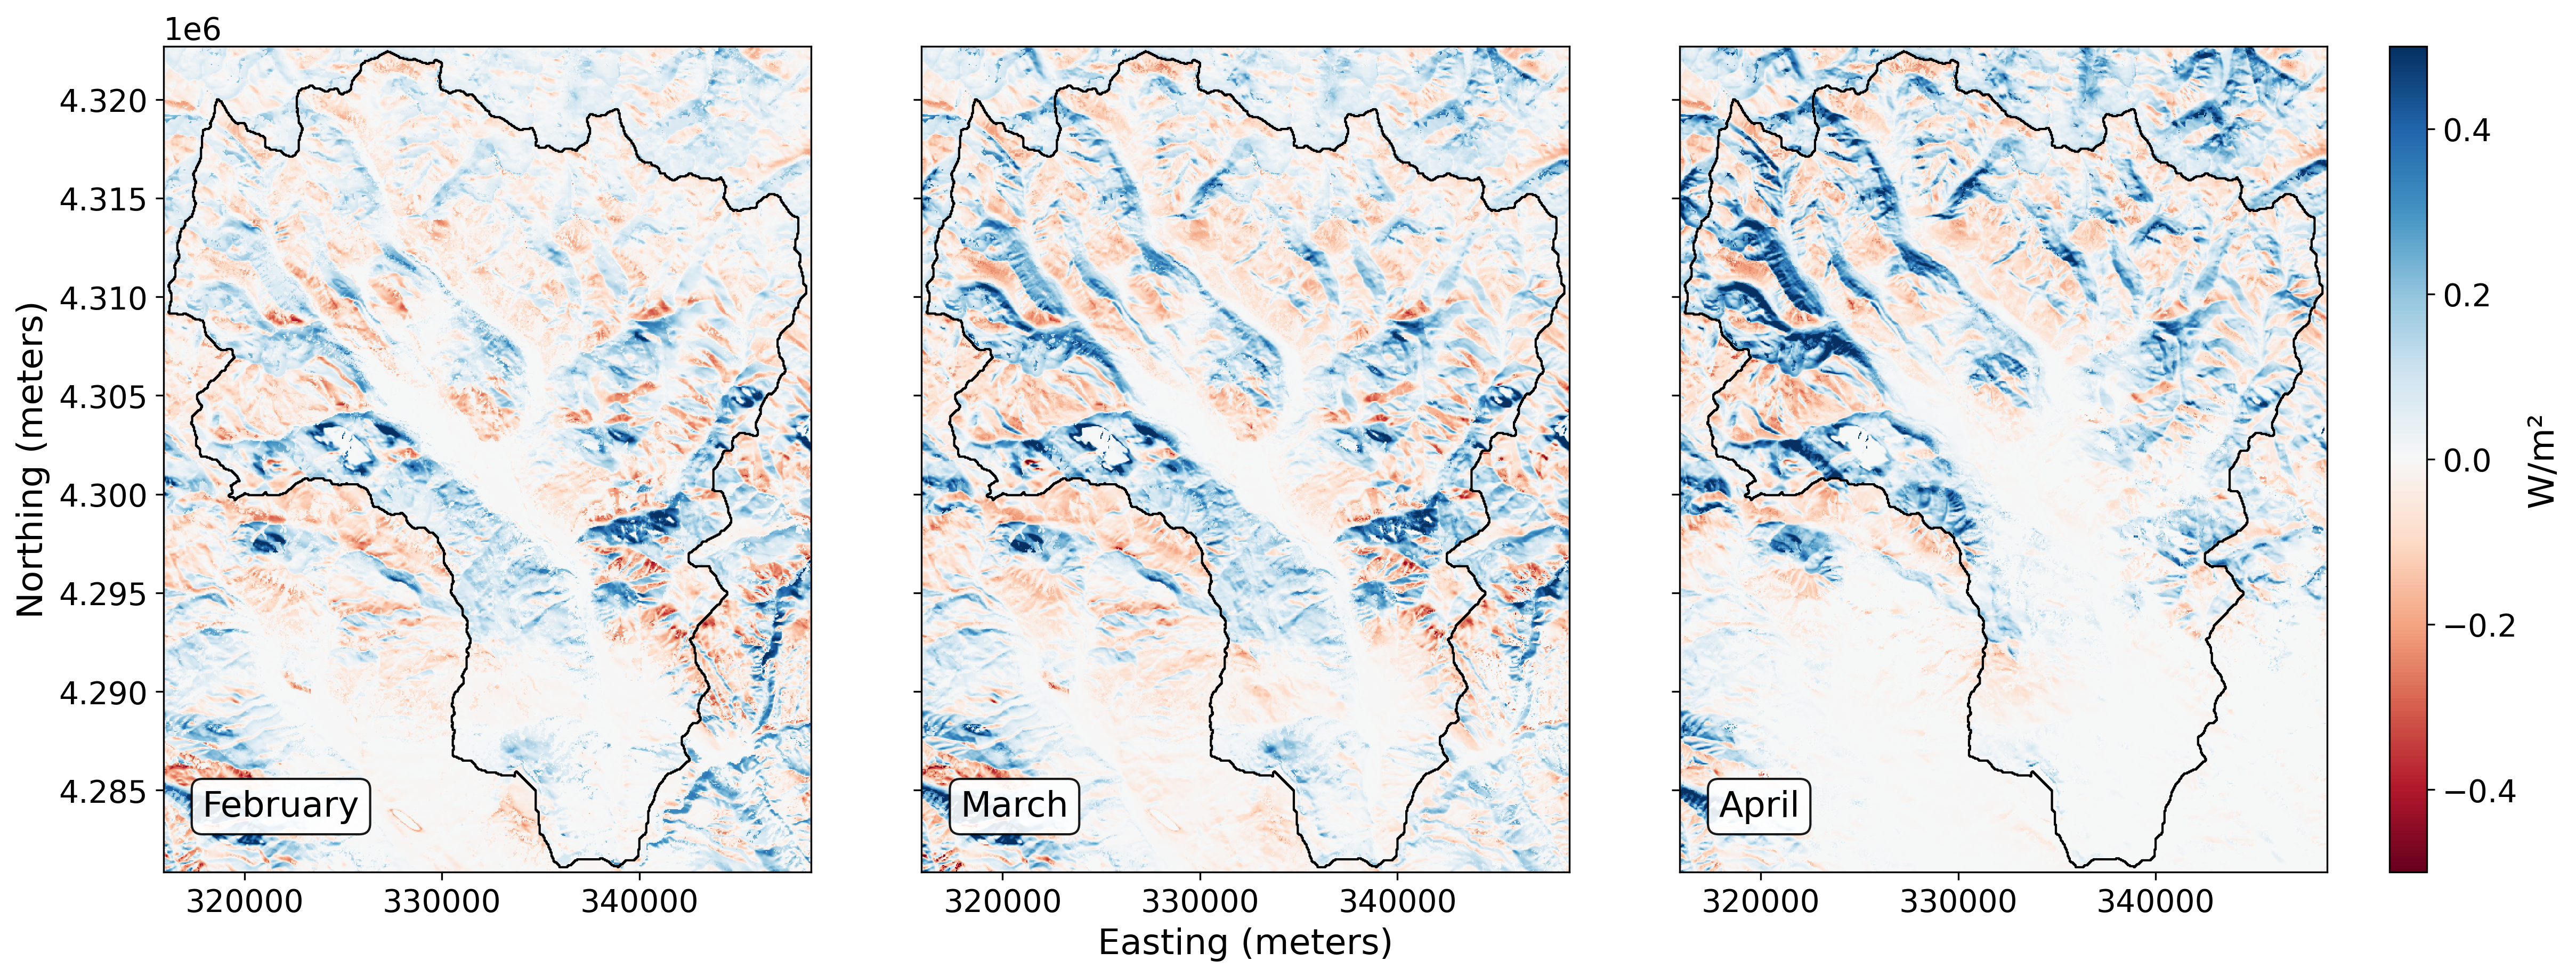

In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Global font settings
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})

# Color limits and colormap
vmin = min([float(apr1.min()), float(apr2.min()), float(apr3.min())])
vmax = max([float(apr1.max()), float(apr2.max()), float(apr3.max())])
vmin, vmax = -0.5, 0.5
# vmin, vmax = -1, 1
abs_max = max(abs(vmin), abs(vmax))
cmap = 'RdBu'
# cmap = 'PuOr_r'

# Set up figure with GridSpec for clean layout including colorbar
fig = plt.figure(figsize=(16, 6), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(1, 4, figure=fig, width_ratios=[1, 1, 1, 0.05])

# Axes for plots
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
cax = fig.add_subplot(gs[3])  # Colorbar axis

# Plot datasets in order: dsw1_base, dsw3_shade, dsw3_base
im0 = feb1.plot(ax=ax0, cmap=cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=False)
mar1.plot(ax=ax1, cmap=cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=False)
apr1.plot(ax=ax2, cmap=cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=False)


# Overlay polygons with no fill, just boundaries
gdf.plot(ax=ax0, facecolor='none', edgecolor='black', linewidth=1)
gdf.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1)
gdf.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=1)
# import matplotlib.patches as patches

# Add shared colorbar
cbar = fig.colorbar(im0, cax=cax, orientation='vertical')
cbar.set_label('W/m²', fontsize=16)

# Titles inside each plot
titles = ['February', 'March', 'April']
# titles = [r'$\cos(\theta_i)$', r'S & $V_f$', 'Toposplit']
for ax, title in zip([ax0, ax1, ax2], titles):
    ax.text(0.06, 0.10, title, transform=ax.transAxes,
            fontsize=16, va='top', ha='left', # fontweight='bold', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

# Axis labels
ax0.set_ylabel('Northing (meters)')
for ax in [ax1, ax2]:
    ax.set_ylabel('')
    ax.set_yticklabels([])

for ax in [ax0, ax1, ax2]:
    ax.tick_params(axis='x', labelrotation=0)

ax0.set_xlabel('')
ax1.set_xlabel('Easting (meters)')
ax2.set_xlabel('')

plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'fig-spatial-month-snow.png', dpi=300, bbox_inches='tight')

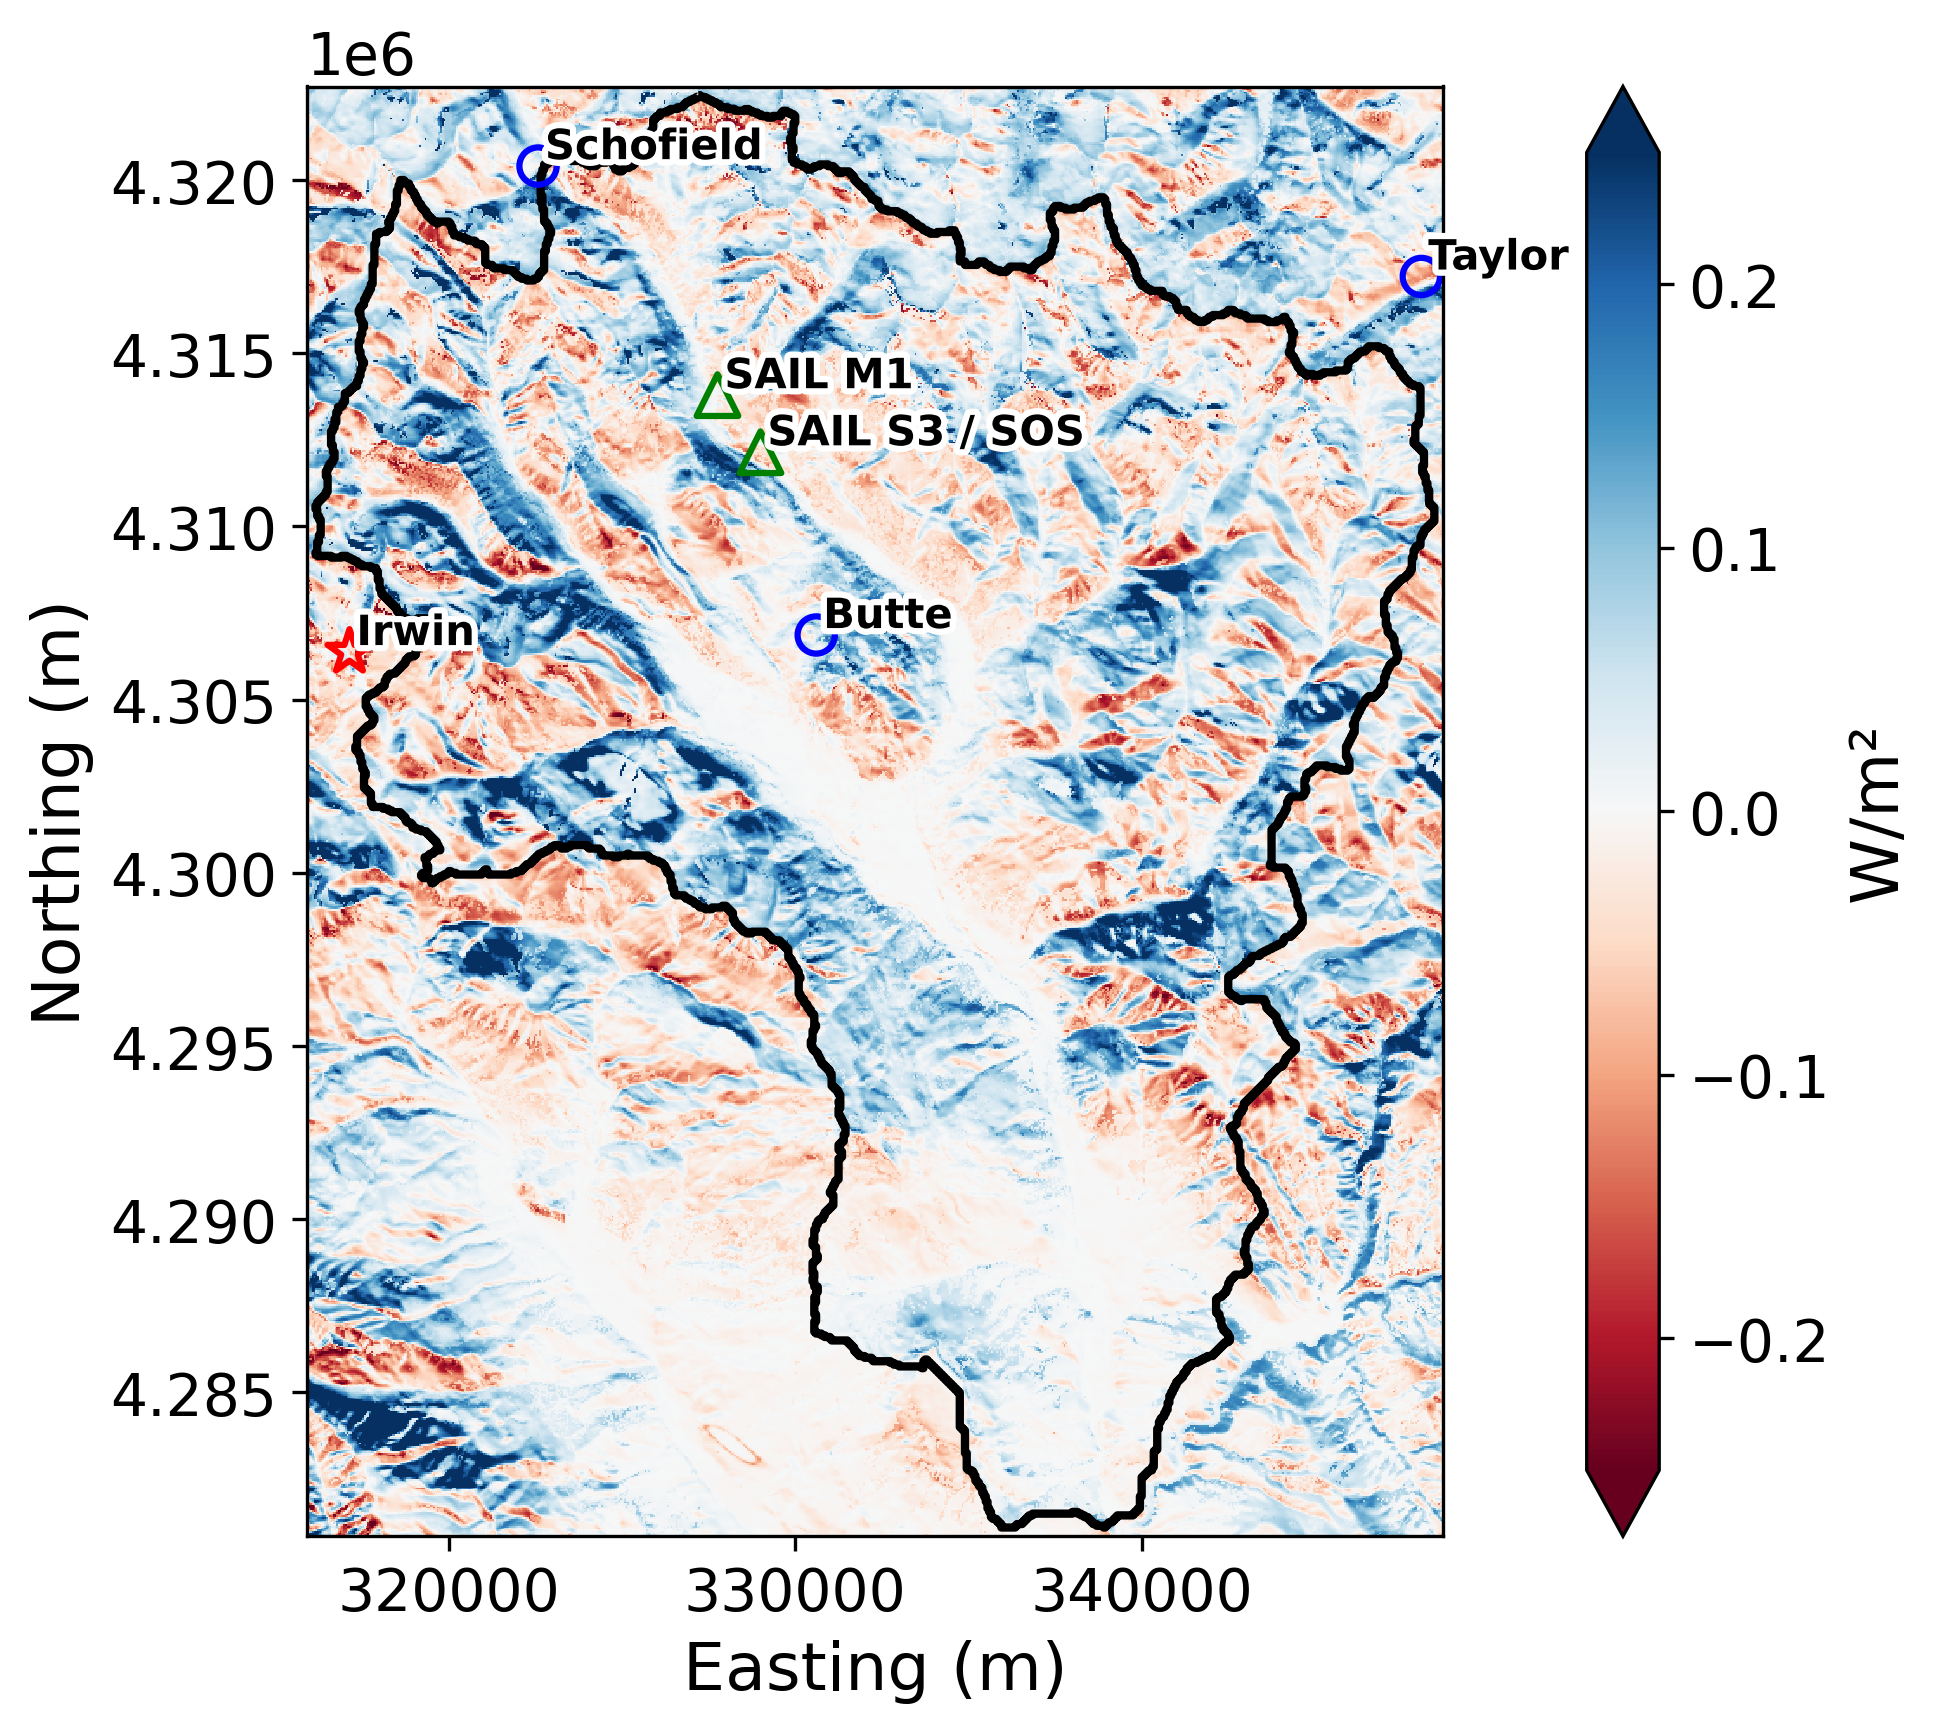

In [17]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import xarray as xr
import matplotlib.patheffects as path_effects

# --- UTM Zone 13N CRS ---
crs_utm13n = "EPSG:32613"

# --- Define points ---
triangle_points = {
    "SAIL M1": (327754.55, 4313790.30),
    "SAIL S3 / SOS": (328995.37, 4312141.89),
    # "SOS": (328982.06, 4312159.61)
}

circle_points = {
    "Irwin": (317131, 4306375),
    "Butte": (330605, 4306866),
    "Schofield": (322574, 4320403),
    "Taylor": (348074, 4317216)
}

# --- Create GeoDataFrames ---
triangles_gdf = gpd.GeoDataFrame({
    "name": list(triangle_points.keys()),
    "geometry": [Point(xy) for xy in triangle_points.values()]
}, crs=crs_utm13n)

circles_gdf = gpd.GeoDataFrame({
    "name": list(circle_points.keys()),
    "geometry": [Point(xy) for xy in circle_points.values()]
}, crs=crs_utm13n)

# Separate out Irwin
irwin_gdf = circles_gdf[circles_gdf['name'] == 'Irwin']
other_circles = circles_gdf[circles_gdf['name'] != 'Irwin']

# --- Color limits and colormap ---
vmin = float(dsw3_base.min())
vmax = float(dsw3_base.max())
vmin, vmax = -100, 100
vmin, vmax = -.25, .25
abs_max = max(abs(vmin), abs(vmax))
cmap = 'RdBu'
# cmap = 'PuOr_r'

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Plot raster
im = dsw3_base.plot(ax=ax, cmap=cmap, vmin=-abs_max, vmax=abs_max,
                    cbar_kwargs={'label': 'W/m²'})

gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2)


# Plot points
# triangles_gdf.plot(ax=ax, marker='^', color='green', markersize=100)
# other_circles.plot(ax=ax, marker='o', color='blue', markersize=80)
# irwin_gdf.plot(ax=ax, marker='*', color='red', markersize=120)
#
triangles_gdf.plot(ax=ax, marker='^', facecolor='none', edgecolor='green', linewidth=1.5, markersize=100)
other_circles.plot(ax=ax, marker='o', facecolor='none', edgecolor='blue', linewidth=1.5, markersize=80)
irwin_gdf.plot(ax=ax, marker='*', facecolor='none', edgecolor='red', linewidth=1.5, markersize=120)


# Label path effects (white outline for readability)
label_effect = [path_effects.Stroke(linewidth=3, foreground='white'),
                path_effects.Normal()]

# Add text labels
for df in [triangles_gdf, other_circles, irwin_gdf]:
    for _, row in df.iterrows():
        ax.text(row.geometry.x + 200, row.geometry.y + 200, row['name'],
                fontsize=10, color='black', fontweight='bold',
                path_effects=label_effect)

# Finalize
# ax.set_title("dsw3_base with Measurement Sites")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()

plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'fig-spatial-sites-DecMay-snow-25.png', dpi=300, bbox_inches='tight')

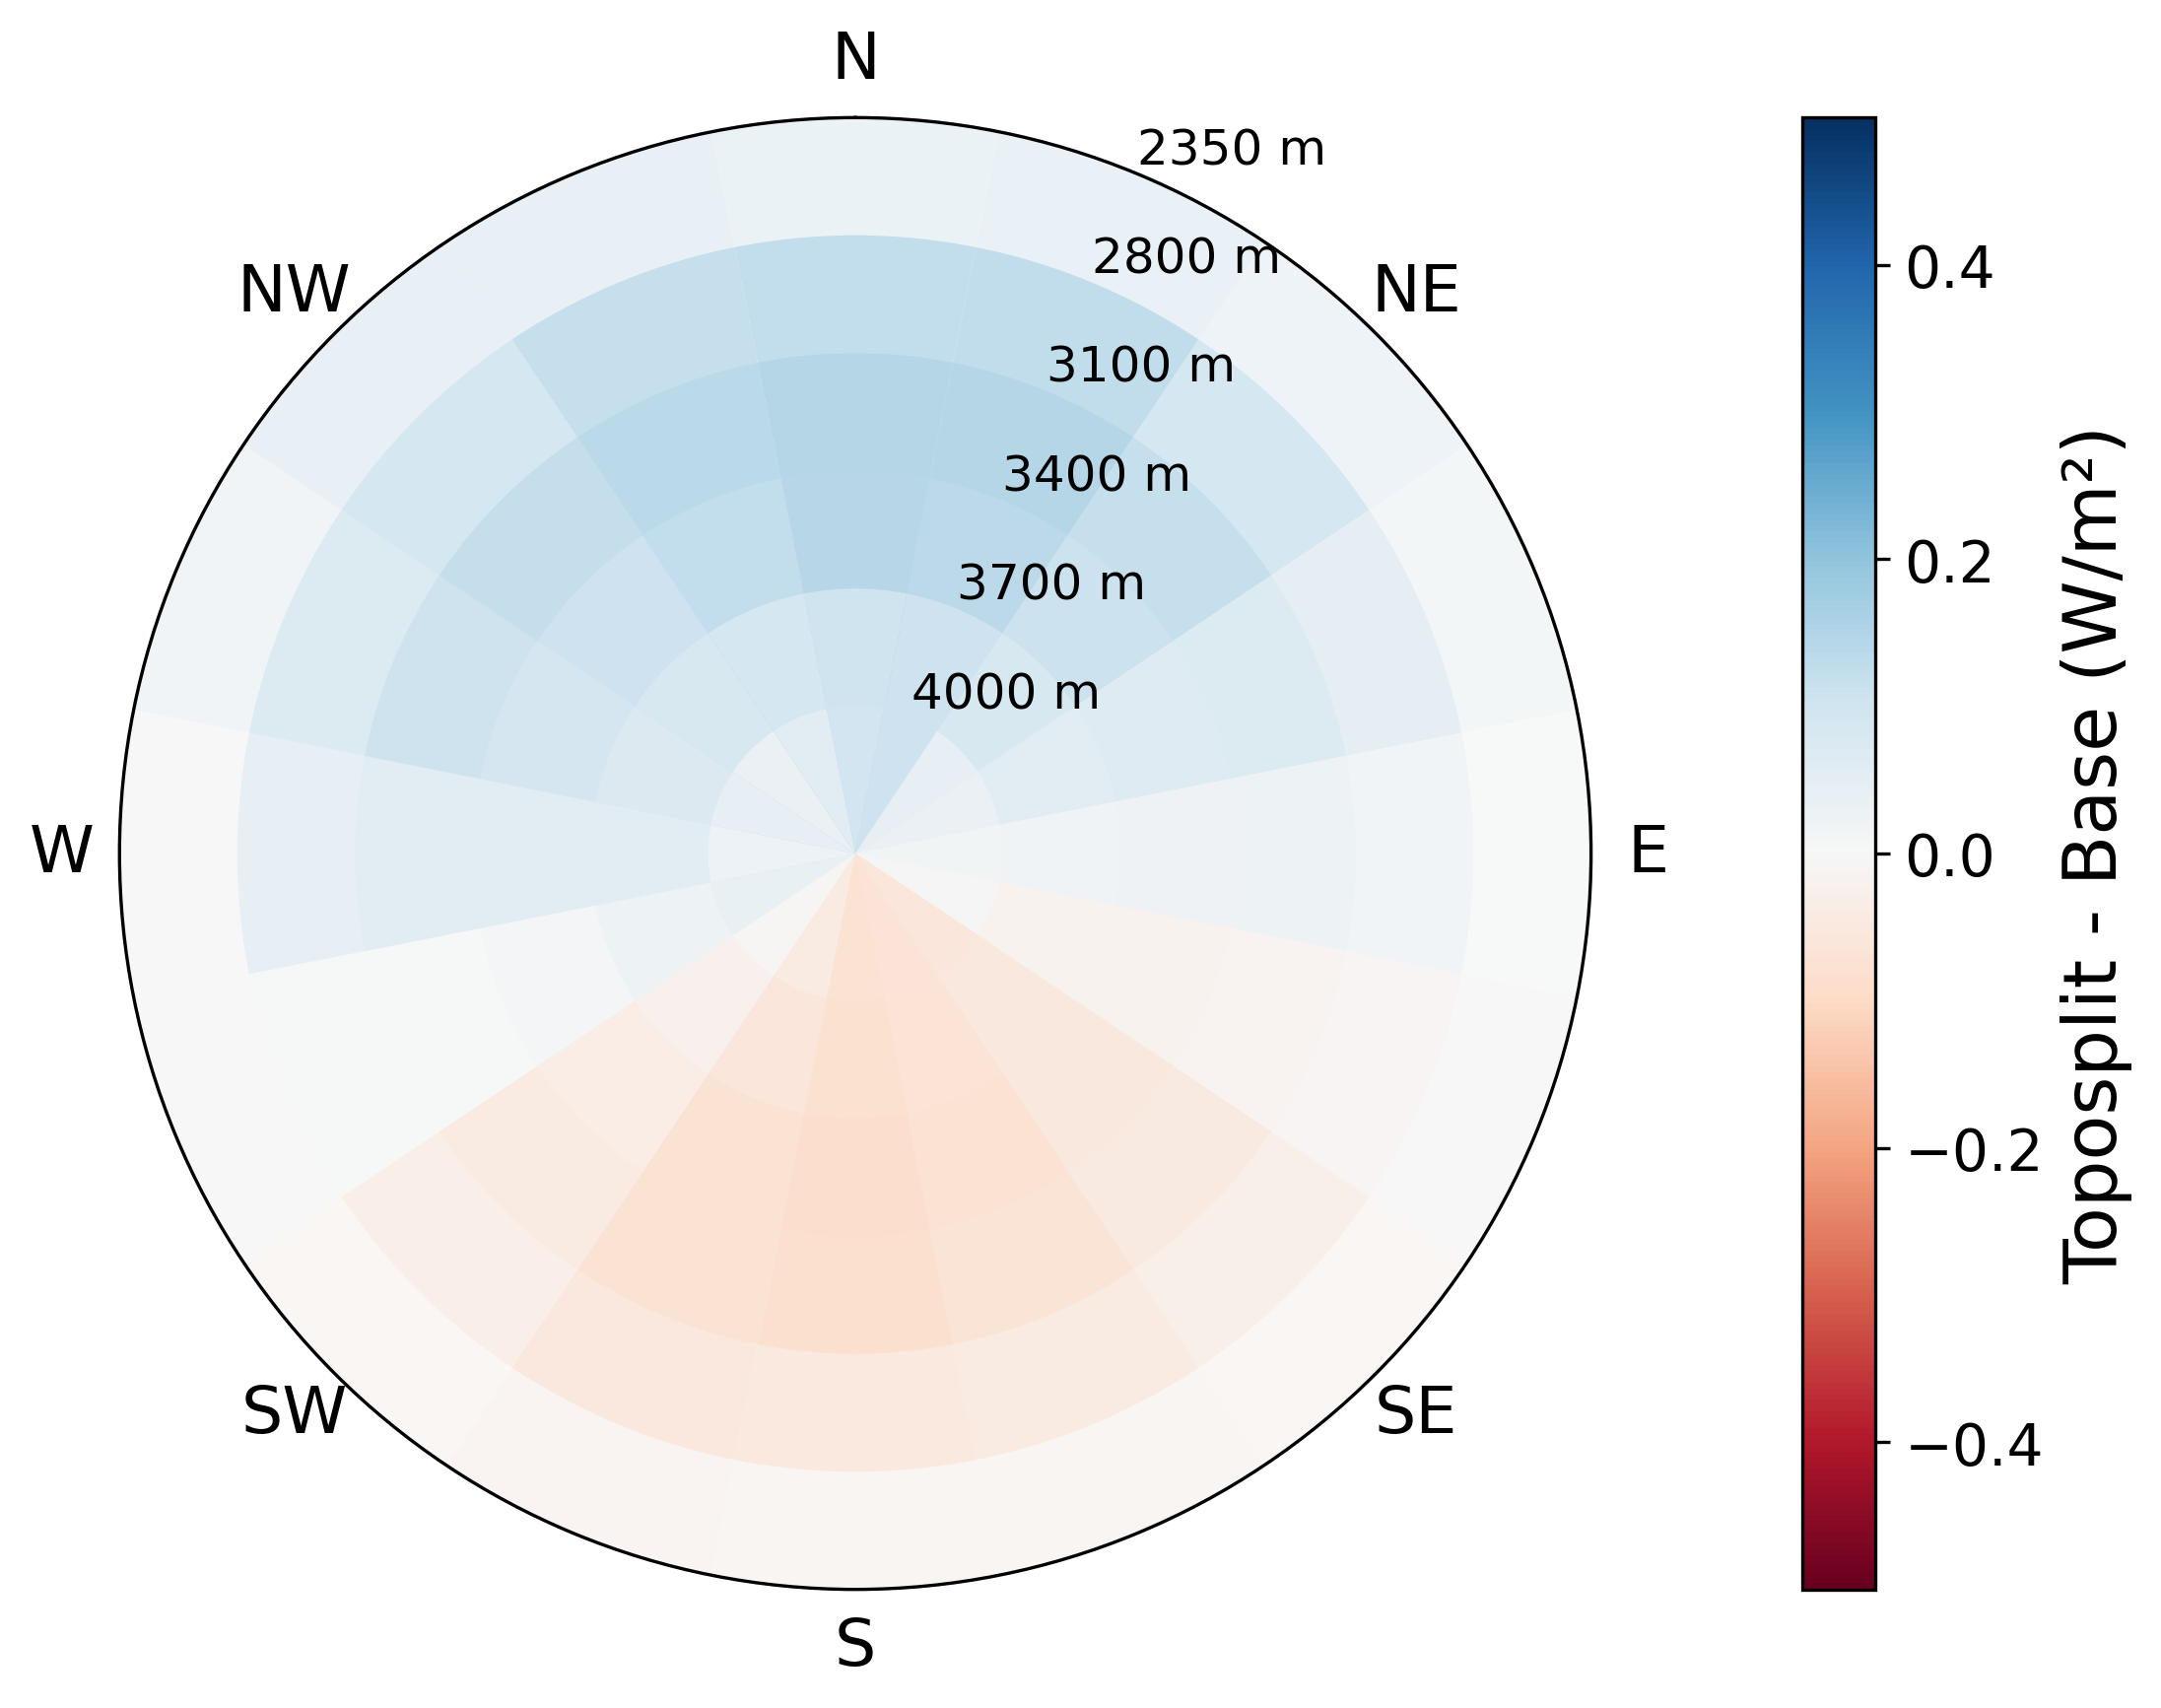

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects

# --- Load the DEM and mask ---
dem_ds = xr.open_dataset(ERW_TOPO_FILE)  # Replace with your DEM file
dem = dem_ds["dem"]
mask = dem_ds["mask"]  # binary mask (1 = valid, 0 = invalid)

# # #  # #

# --- Compute aspect ---
# Calculate gradients (assumes regular grid)
# dy, dx = np.gradient(dem.values, dem.y.values, dem.x.values)

# # aspect = np.arctan2(-dx, dy)  # In radians
# aspect = np.arctan2(dy, -dx)
# aspect = np.degrees(aspect)
# aspect = (aspect + 90) % 360  # Convert to 0-360 degrees

pth = "/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/isnobal-data/dem_asp_mask.nc"
dem_2 = xr.open_dataset(pth)  
aspect = dem_2.variable.sel(z=2).values

# # # #

# Mask where elevation is nan or mask==0
mask_bool = (mask.values == 1) & ~np.isnan(dem.values) & ~np.isnan(dsw3_base.values)
# mask_bool = ~np.isnan(dem.values) 

# Apply mask to all variables
elevation = dem.values[mask_bool]
aspects = aspect[mask_bool]
dsw_values = dsw3_base.values[mask_bool]  # Use dsw3_base instead of peak_swe_shift

# --- Bin aspect and elevation ---
num_aspect_bins = 16
aspect_bins = np.linspace(0, 360, num_aspect_bins + 1)
aspect_binned = np.digitize(aspects, aspect_bins) - 1  # 0-based indexing

elevation_bins = [2500, 2700, 2900, 3200, 3500, 3700, 4000, 4300]
elevation_bins = [2350, 2800, 3100, 3400, 3700, 4000, 4450]
elevation_binned = np.digitize(elevation, elevation_bins) - 1

# --- Aggregate dsw3_base by aspect and elevation bins ---
aggregated_values = []
for aspect_bin in range(num_aspect_bins):
    for elev_bin in range(len(elevation_bins) - 1):
        m = (aspect_binned == aspect_bin) & (elevation_binned == elev_bin)
        vals = dsw_values[m]
        aggregated_values.append(np.mean(vals) if len(vals) > 0 else np.nan)
aggregated_values = np.array(aggregated_values)

# --- Plot rose diagram ---
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 6), dpi=300)

angles = np.linspace(0, 2 * np.pi, num_aspect_bins, endpoint=False)
radius = np.linspace(1, 0.2, len(elevation_bins) - 1)

# Normalize color range for dsw3_base
vmin, vmax = -100, 100  # Adjust based on your range
vmin, vmax = -.25, .25
# cmap = cm.BuPu_r
# cmap = cm.PuOr_r
cmap = cm.RdBu
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
bar_width = 2 * np.pi / num_aspect_bins

# Plot bars
for aspect_bin in range(num_aspect_bins):
    for elev_bin in range(len(elevation_bins) - 1):
        idx = aspect_bin * (len(elevation_bins) - 1) + elev_bin
        val = aggregated_values[idx]
        color = cmap(norm(val)) if not np.isnan(val) else "lightgray"
        ax.bar(angles[aspect_bin], radius[elev_bin],
               width=bar_width, bottom=0, color=color, alpha=0.8)

# Set polar plot properties
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

aspect_labels = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
                 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
aspect_labels = ['N', '', 'NE', '', 'E', '', 'SE', '',
                 'S', '', 'SW', '', 'W', '', 'NW', '']
ax.set_xticks(angles)
ax.set_xticklabels(aspect_labels, size=16)

ax.set_yticks(radius)
ax.set_yticklabels([f"{elev} m" for elev in elevation_bins[:-1]], size=12, color="white")
ax.set_ylim(0, 1)
ax.grid(False)

# Colorbar
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.1)
# cbar.set_label('Mean dsw3_base (W/m²)', fontsize=14)
cbar.set_label('Toposplit - Base (W/m²)', size =18)

# Title
ax.set_title("", size=16, pad=20)

plt.tight_layout()
plt.show()

# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'fig-polar-diff-DecMay-snow-25', dpi=300, bbox_inches='tight')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Global font settings
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})

# Color limits and colormap
vmin = min([float(apr1.min()), float(apr2.min()), float(apr3.min()), float(may1.min())])
vmax = max([float(apr1.max()), float(apr2.max()), float(apr3.max()), float(may1.max())])
abs_max = max(abs(vmin), abs(vmax))
cmap = 'RdBu'
# cmap = 'PuOr_r'

# Set up figure with GridSpec for clean layout including colorbar
fig = plt.figure(figsize=(20, 6), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(1, 5, figure=fig, width_ratios=[1, 1, 1, 1, 0.05])  # 4 plots + 1 colorbar

# Axes for plots
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax3 = fig.add_subplot(gs[3])  # New axis for May
cax = fig.add_subplot(gs[4])  # Colorbar axis

# Plot datasets
im0 = feb1.plot(ax=ax0, cmap=cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=False)
mar1.plot(ax=ax1, cmap=cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=False)
apr1.plot(ax=ax2, cmap=cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=False)
may1.plot(ax=ax3, cmap=cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=False)  # May plot

# Overlay polygons
for ax in [ax0, ax1, ax2, ax3]:
    gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2)

# Add shared colorbar
cbar = fig.colorbar(im0, cax=cax, orientation='vertical')
cbar.set_label('W/m²', fontsize=16)

# Titles inside each plot
titles = ['February', 'March', 'April', 'May']
for ax, title in zip([ax0, ax1, ax2, ax3], titles):
    ax.text(0.06, 0.10, title, transform=ax.transAxes,
            fontsize=16, va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

# Axis labels
ax0.set_ylabel('Northing (meters)')
for ax in [ax1, ax2, ax3]:
    ax.set_ylabel('')
    ax.set_yticklabels([])

for ax in [ax0, ax1, ax2, ax3]:
    ax.tick_params(axis='x', labelrotation=0)

ax0.set_xlabel('')
ax1.set_xlabel('Easting (meters)')
ax2.set_xlabel('')
ax3.set_xlabel('')

plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'fig-spatial-month-means-black.png', dpi=300, bbox_inches='tight')
